In [2]:
import pandas as pd

# Define the path to your dataset
# Assuming benin-malanville.csv is in the root data/ directory
# Adjust the path if your file is located elsewhere relative to the notebook
file_path = '/home/y/Downloads/data/benin-malanville.csv'   

# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
    print("Please check the file path and make sure 'benin-malanville.csv' is in a 'data' folder in your project root.")

# Display the first few rows of the DataFrame to check it loaded correctly
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Display the column names and their data types
print("\nDataset Info:")
df.info()

Dataset loaded successfully!

First 5 rows of the dataset:
          Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0  2021-08-09 00:01 -1.2 -0.2 -1.1   0.0   0.0  26.2  93.4  0.0     0.4   
1  2021-08-09 00:02 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.6  0.0     0.0   
2  2021-08-09 00:03 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.7  0.3     1.1   
3  2021-08-09 00:04 -1.1 -0.1 -1.0   0.0   0.0  26.2  93.3  0.2     0.7   
4  2021-08-09 00:05 -1.0 -0.1 -1.0   0.0   0.0  26.2  93.3  0.1     0.7   

   WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  TModA  TModB  \
0      0.1  122.1      0.0  998         0            0.0   26.3   26.2   
1      0.0    0.0      0.0  998         0            0.0   26.3   26.2   
2      0.5  124.6      1.5  997         0            0.0   26.4   26.2   
3      0.4  120.3      1.3  997         0            0.0   26.4   26.3   
4      0.3  113.2      1.0  997         0            0.0   26.4   26.3   

   Comments  
0       NaN  
1       NaN  
2  

In [3]:
# Perform df.describe() on all numeric columns
print("Summary Statistics for Numeric Columns:")
print(df.describe())

# Perform df.isna().sum() to get the count of missing values per column
print("\nMissing Value Count per Column:")
missing_values = df.isna().sum()
print(missing_values)

# List any column with >5% nulls
print("\nColumns with >5% Missing Values:")
total_rows = len(df)
for column, count in missing_values.items():
    percentage = (count / total_rows) * 100
    if percentage > 5:
        print(f"- {column}: {count} missing values ({percentage:.2f}%)")

Summary Statistics for Numeric Columns:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      240.559452     167.187516     115.358961     236.589496   
std       331.131327     261.710501     158.691074     326.894859   
min       -12.900000      -7.800000     -12.600000       0.000000   
25%        -2.000000      -0.500000      -2.100000       0.000000   
50%         1.800000      -0.100000       1.600000       4.500000   
75%       483.400000     314.200000     216.300000     463.700000   
max      1413.000000     952.300000     759.200000    1342.300000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      228.883576      28.179683      54.487969       2.121113   
std       316.536515       5.924297      28.073069       1.603466   
min         0.000000      11.000000       2.100000       0.000

In [4]:
import numpy as np
from scipy.stats import zscore

# --- Outlier Detection (using Z-scores) ---

# Define the columns to check for outliers
outlier_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

print("Calculating Z-scores for outlier detection...")

# Calculate Z-scores for the specified columns
# We use np.abs() to get the absolute Z-score
z_scores = df[outlier_cols].apply(zscore, nan_policy='omit') # 'omit' ignores potential NaNs, though our report showed none in these cols

# Flag rows where the absolute Z-score is greater than 3 in any of the specified columns
# We create a boolean mask
outlier_mask = (np.abs(z_scores) > 3).any(axis=1)

# Add a new column to the DataFrame to flag potential outlier rows
df['Potential_Outlier_Zscore'] = outlier_mask

print(f"\nNumber of rows potentially flagged as outliers based on Z-score (>3): {outlier_mask.sum()}")
print("\nFirst 5 rows with outlier flag:")
print(df[['Timestamp'] + outlier_cols + ['Potential_Outlier_Zscore']].head()) # Display head with relevant columns

# You can inspect rows flagged as outliers if needed:
# print("\nExamples of rows flagged as potential outliers:")
# print(df[df['Potential_Outlier_Zscore']].head())


# --- Basic Cleaning (Handling Missing Values) ---

# We identified that the 'Comments' column is 100% missing.
# It provides no information, so we will drop it.
print("\nHandling missing values...")
if 'Comments' in df.columns:
    df = df.drop('Comments', axis=1)
    print("Dropped the 'Comments' column due to 100% missing values.")
else:
    print("'Comments' column not found or already dropped.")

# For other columns, if you had <5% missing values that you wanted to impute (e.g., with median),
# you would add code here. Based on our report, other columns have 0 missing values,
# so imputation is not needed for them at this stage.
# Example (if needed for other columns):
# for col in df.columns:
#     if df[col].isna().sum() > 0 and df[col].isna().sum() / len(df) <= 0.05:
#         median_val = df[col].median()
#         df[col].fillna(median_val, inplace=True)
#         print(f"Imputed missing values in '{col}' with median ({median_val}).")


print("\nCleaning steps completed.")
print("\nDataset Info after dropping 'Comments' column:")
df.info() # Check info again to see 'Comments' is gone

Calculating Z-scores for outlier detection...

Number of rows potentially flagged as outliers based on Z-score (>3): 7740

First 5 rows with outlier flag:
          Timestamp  GHI  DNI  DHI  ModA  ModB   WS  WSgust  \
0  2021-08-09 00:01 -1.2 -0.2 -1.1   0.0   0.0  0.0     0.4   
1  2021-08-09 00:02 -1.1 -0.2 -1.1   0.0   0.0  0.0     0.0   
2  2021-08-09 00:03 -1.1 -0.2 -1.1   0.0   0.0  0.3     1.1   
3  2021-08-09 00:04 -1.1 -0.1 -1.0   0.0   0.0  0.2     0.7   
4  2021-08-09 00:05 -1.0 -0.1 -1.0   0.0   0.0  0.1     0.7   

   Potential_Outlier_Zscore  
0                     False  
1                     False  
2                     False  
3                     False  
4                     False  

Handling missing values...
Dropped the 'Comments' column due to 100% missing values.

Cleaning steps completed.

Dataset Info after dropping 'Comments' column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column   

In [5]:
import os

# Define the path for the output directory and file
output_dir = '../data/'
output_file_path = os.path.join(output_dir, 'benin_clean.csv')

# Ensure the output directory exists
# The os.makedirs() function will create the directory if it doesn't exist.
# exist_ok=True prevents an error if the directory already exists.
print(f"Ensuring directory '{output_dir}' exists...")
os.makedirs(output_dir, exist_ok=True)
print(f"Directory '{output_dir}' checked/created.")


# Export the cleaned DataFrame to a CSV file
# index=False prevents pandas from writing the DataFrame index as a column in the CSV
print(f"\nExporting cleaned data to '{output_file_path}'...")
df.to_csv(output_file_path, index=False)
print("Cleaned data exported successfully!")

Ensuring directory '../data/' exists...
Directory '../data/' checked/created.

Exporting cleaned data to '../data/benin_clean.csv'...
Cleaned data exported successfully!


Converting 'Timestamp' column to datetime...
'Timestamp' column converted to datetime.

Generating Time Series Plots for GHI, DNI, DHI, and Tamb...


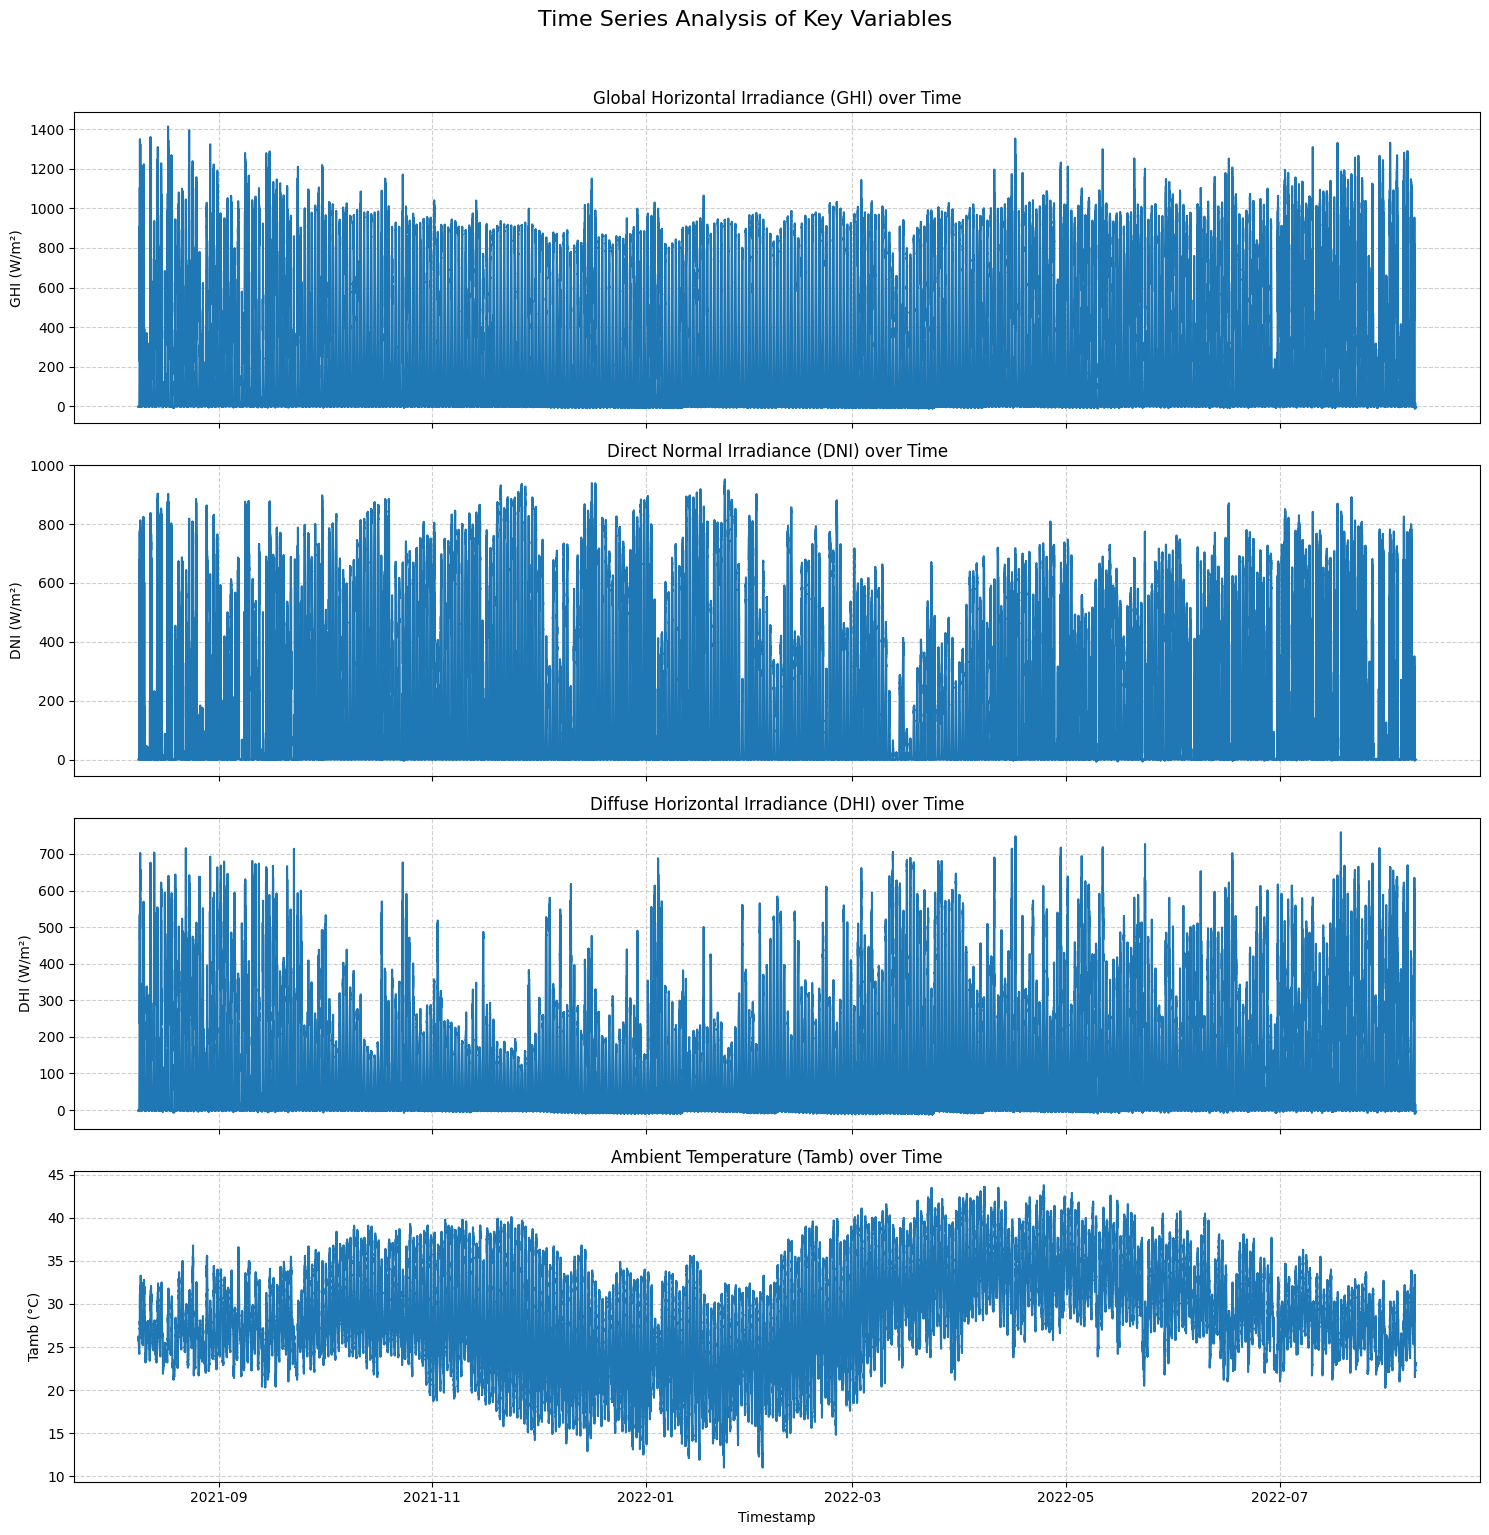


Time Series Plots generated.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Prepare Timestamp Column ---

print("Converting 'Timestamp' column to datetime...")
# Convert the 'Timestamp' column to datetime objects
# coerce errors will turn unparseable dates into NaT (Not a Time)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
print("'Timestamp' column converted to datetime.")

# It's often useful to set the Timestamp as the DataFrame index for time series analysis,
# but for plotting specific columns against Timestamp, keeping it as a column is also fine.
# If you wanted to set it as index, you would use:
# df = df.set_index('Timestamp')


# --- Time Series Analysis Plots ---

print("\nGenerating Time Series Plots for GHI, DNI, DHI, and Tamb...")

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 15), sharex=True)
fig.suptitle('Time Series Analysis of Key Variables', y=1.02, fontsize=16) # Add a title for the whole figure

# Plot GHI vs Timestamp
sns.lineplot(ax=axes[0], x=df['Timestamp'], y=df['GHI'])
axes[0].set_title('Global Horizontal Irradiance (GHI) over Time')
axes[0].set_ylabel('GHI (W/m²)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot DNI vs Timestamp
sns.lineplot(ax=axes[1], x=df['Timestamp'], y=df['DNI'])
axes[1].set_title('Direct Normal Irradiance (DNI) over Time')
axes[1].set_ylabel('DNI (W/m²)')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot DHI vs Timestamp
sns.lineplot(ax=axes[2], x=df['Timestamp'], y=df['DHI'])
axes[2].set_title('Diffuse Horizontal Irradiance (DHI) over Time')
axes[2].set_ylabel('DHI (W/m²)')
axes[2].grid(True, linestyle='--', alpha=0.6)

# Plot Tamb vs Timestamp
sns.lineplot(ax=axes[3], x=df['Timestamp'], y=df['Tamb'])
axes[3].set_title('Ambient Temperature (Tamb) over Time')
axes[3].set_ylabel('Tamb (°C)')
axes[3].set_xlabel('Timestamp') # Only the bottom plot needs the x-label
axes[3].grid(True, linestyle='--', alpha=0.6)


# Improve layout and display the plots
plt.tight_layout()
plt.show()

print("\nTime Series Plots generated.")

Analyzing Cleaning Impact on average ModA and ModB...

Average ModA and ModB grouped by Cleaning flag (0: No Cleaning, 1: Cleaning):
                ModA        ModB
Cleaning                        
0         236.524253  228.816071
1         307.229278  301.972165


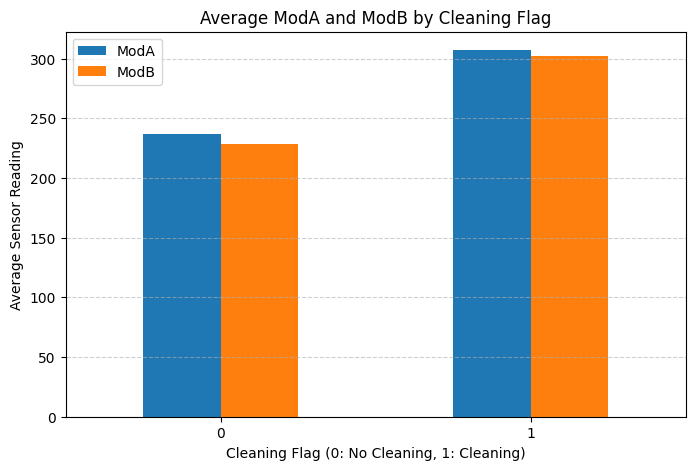


Cleaning Impact analysis completed.


In [7]:
# --- Cleaning Impact Analysis ---

print("Analyzing Cleaning Impact on average ModA and ModB...")

# Group the DataFrame by the 'Cleaning' column and calculate the mean of ModA and ModB
cleaning_impact = df.groupby('Cleaning')[['ModA', 'ModB']].mean()

print("\nAverage ModA and ModB grouped by Cleaning flag (0: No Cleaning, 1: Cleaning):")
print(cleaning_impact)

# Plot the cleaning impact
cleaning_impact.plot(kind='bar', figsize=(8, 5))
plt.title('Average ModA and ModB by Cleaning Flag')
plt.xlabel('Cleaning Flag (0: No Cleaning, 1: Cleaning)')
plt.ylabel('Average Sensor Reading')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("\nCleaning Impact analysis completed.")

Generating Correlation Heatmap...


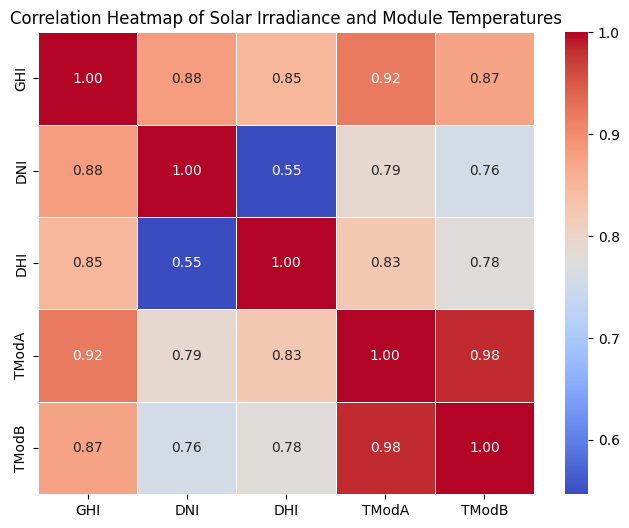


Correlation Heatmap generated.

Generating Scatter Plots...


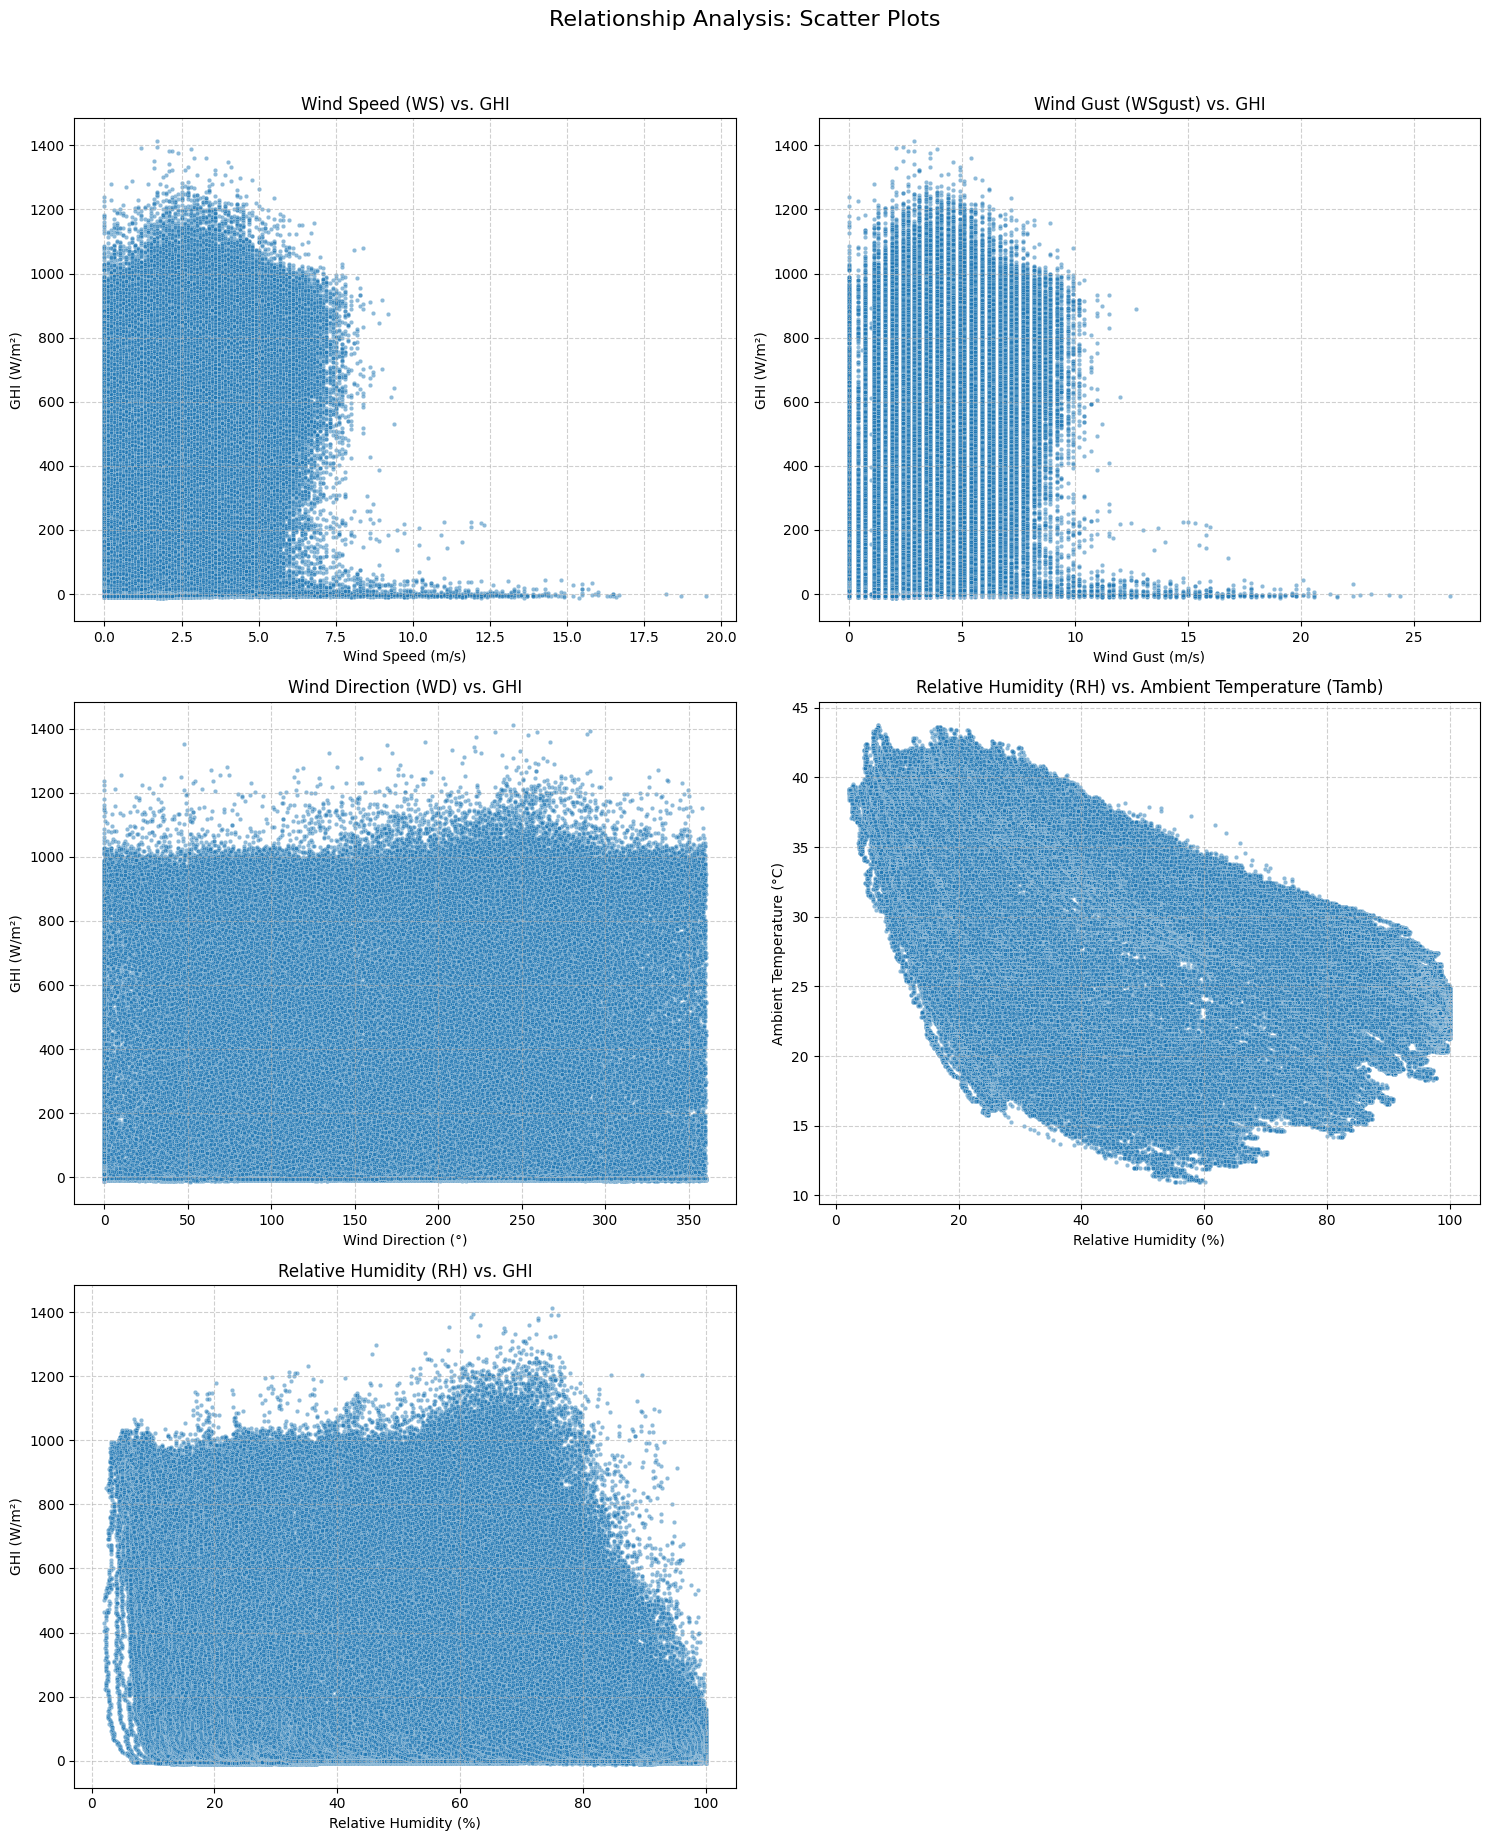


Scatter Plots generated.


In [8]:
# --- Correlation Analysis (Heatmap) ---

print("Generating Correlation Heatmap...")

# Define the columns for the correlation heatmap
heatmap_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']

# Calculate the correlation matrix
correlation_matrix = df[heatmap_cols].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Solar Irradiance and Module Temperatures')
plt.show()

print("\nCorrelation Heatmap generated.")

# --- Relationship Analysis (Scatter Plots) ---

print("\nGenerating Scatter Plots...")

# Create a figure and a set of subplots for scatter plots
# We'll have 2 columns and 3 rows of plots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
fig.suptitle('Relationship Analysis: Scatter Plots', y=1.02, fontsize=16)

# Scatter plot: WS vs GHI
sns.scatterplot(ax=axes[0, 0], x=df['WS'], y=df['GHI'], alpha=0.5, s=10) # s is marker size
axes[0, 0].set_title('Wind Speed (WS) vs. GHI')
axes[0, 0].set_xlabel('Wind Speed (m/s)')
axes[0, 0].set_ylabel('GHI (W/m²)')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# Scatter plot: WSgust vs GHI
sns.scatterplot(ax=axes[0, 1], x=df['WSgust'], y=df['GHI'], alpha=0.5, s=10)
axes[0, 1].set_title('Wind Gust (WSgust) vs. GHI')
axes[0, 1].set_xlabel('Wind Gust (m/s)')
axes[0, 1].set_ylabel('GHI (W/m²)')
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# Scatter plot: WD vs GHI - This one is a bit tricky for scatter plot, WD is direction (0-360)
# A scatter plot of WD vs GHI might not show clear patterns directly.
# Let's plot it anyway as requested, but keep in mind other plots (like wind rose later) are better for WD distribution.
sns.scatterplot(ax=axes[1, 0], x=df['WD'], y=df['GHI'], alpha=0.5, s=10)
axes[1, 0].set_title('Wind Direction (WD) vs. GHI')
axes[1, 0].set_xlabel('Wind Direction (°)')
axes[1, 0].set_ylabel('GHI (W/m²)')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Scatter plot: RH vs Tamb
sns.scatterplot(ax=axes[1, 1], x=df['RH'], y=df['Tamb'], alpha=0.5, s=10)
axes[1, 1].set_title('Relative Humidity (RH) vs. Ambient Temperature (Tamb)')
axes[1, 1].set_xlabel('Relative Humidity (%)')
axes[1, 1].set_ylabel('Ambient Temperature (°C)')
axes[1, 1].grid(True, linestyle='--', alpha=0.6)


# Scatter plot: RH vs GHI
sns.scatterplot(ax=axes[2, 0], x=df['RH'], y=df['GHI'], alpha=0.5, s=10)
axes[2, 0].set_title('Relative Humidity (RH) vs. GHI')
axes[2, 0].set_xlabel('Relative Humidity (%)')
axes[2, 0].set_ylabel('GHI (W/m²)')
axes[2, 0].grid(True, linestyle='--', alpha=0.6)

# Hide the unused subplot
fig.delaxes(axes[2, 1])

# Improve layout and display the plots
plt.tight_layout()
plt.show()

print("\nScatter Plots generated.")

Generating Histograms for GHI and WS...


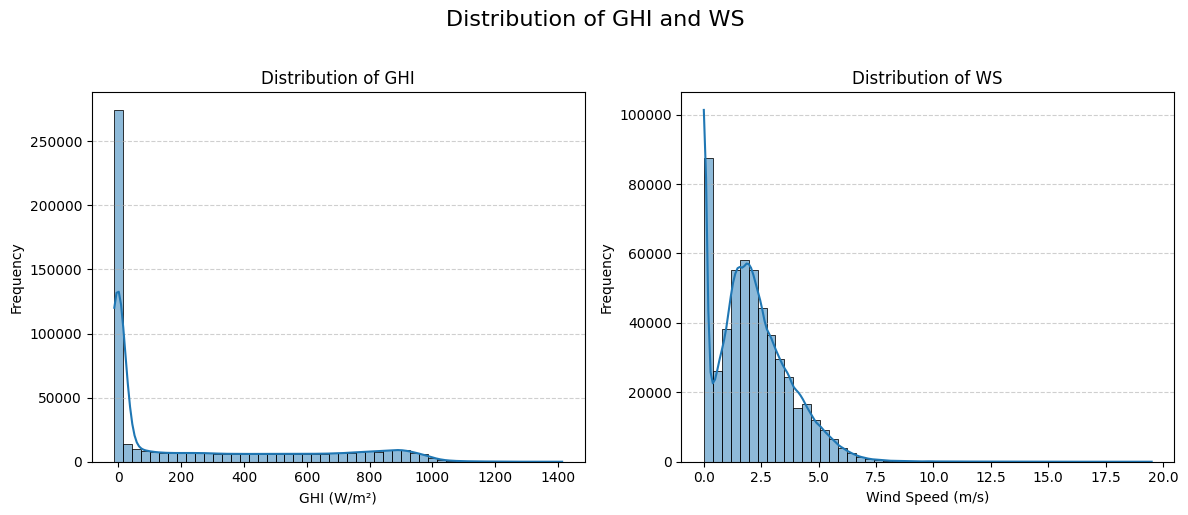


Histograms generated.


In [9]:
# --- Distribution Analysis (Histograms) ---

print("Generating Histograms for GHI and WS...")

# Create a figure and a set of subplots for histograms
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
fig.suptitle('Distribution of GHI and WS', y=1.02, fontsize=16)

# Histogram for GHI
sns.histplot(ax=axes[0], data=df, x='GHI', kde=True, bins=50) # kde=True adds a density curve
axes[0].set_title('Distribution of GHI')
axes[0].set_xlabel('GHI (W/m²)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Histogram for WS
sns.histplot(ax=axes[1], data=df, x='WS', kde=True, bins=50)
axes[1].set_title('Distribution of WS')
axes[1].set_xlabel('Wind Speed (m/s)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

print("\nHistograms generated.")

In [5]:
# --- Wind Analysis (Wind Rose) ---

print("\nGenerating Wind Rose Plot...")

try:
    from windrose import WindroseAxes
    import matplotlib.cm as cm # Import colormap

    # Create a new figure
    fig = plt.figure(figsize=(10, 10))
    # Create a WindroseAxes instance
    # rect=[left, bottom, width, height] in figure coords
    ax = WindroseAxes.from_ax(fig=fig, rect=[0.1, 0.1, 0.8, 0.8])

    # Plot the wind rose
    # ws is wind speed, wd is wind direction
    # We can specify wind speed bins and colormap
    ax.bar(df['WD'], df['WS'], normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, df['WS'].max() + 1, 2), cmap=cm.viridis)

    # Set title
    ax.set_title('Wind Rose Plot (WS vs WD) - Benin', pad=20)

    # Add legend
    ax.set_legend(title="Wind Speed (m/s)", loc="lower left", bbox_to_anchor=(0.95, 0)) # Position legend outside plot

    plt.show()
    print("Wind Rose Plot generated.")

except ImportError:
    print("The 'windrose' library is not installed.")
    print("Please install it using: pip install windrose in your active terminal environment.")
    print("Skipping Wind Rose plot generation.")
except Exception as e:
    print(f"An error occurred while generating the Wind Rose plot: {e}")


Generating Wind Rose Plot...
The 'windrose' library is not installed.
Please install it using: pip install windrose in your active terminal environment.
Skipping Wind Rose plot generation.
